In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
raw_path = "../data/raw/"
df = pd.read_csv(os.path.join(raw_path, "clean2.data"), header=None)

n_cols = df.shape[1]
columns = ["ID"] + [f"attr_{i}" for i in range(1, n_cols)]
df.columns = columns
df.head()

,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,...,-308,52,-7,39,126,156,-50,-112,96,1.0
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,...,-59,-2,52,103,136,169,-61,-136,79,1.0
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,...,-134,-154,57,143,142,165,-67,-145,39,1.0
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,136,168,-60,-135,80,1.0
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,137,168,-60,-135,80,1.0


In [3]:
#osnovni, brzi pregled podataka
#dimenzije
print("Dimenzije dataset-a:", df.shape)
#provjera nedostajucih vrijednosti
print("Nedostajući podaci po koloni:\n", df.isnull().sum())
#statistika numerickih atributa
print("Opis numeričkih kolona:\n", df.iloc[:,1:].describe())
#broj MUSK i NON-MUSK molekula
num_musk = sum(df['ID'].str.startswith('MUSK'))
num_non_musk = sum(df['ID'].str.startswith('NON-MUSK'))
print(f"MUSK: {num_musk}, NON-MUSK: {num_non_musk}")

Dimenzije dataset-a: (6598, 169)
Nedostajući podaci po koloni:
 ID          0
attr_1      0
attr_2      0
attr_3      0
attr_4      0
           ..
attr_164    0
attr_165    0
attr_166    0
attr_167    0
attr_168    0
Length: 169, dtype: int64
Opis numeričkih kolona:
             attr_2       attr_3       attr_4       attr_5       attr_6  \
count  6598.000000  6598.000000  6598.000000  6598.000000  6598.000000   
mean     58.945135  -119.128524   -73.146560    -0.628372  -103.533495   
std      53.249007    90.813375    67.956235    80.444617    64.387559   
min     -31.000000  -199.000000  -167.000000  -114.000000  -118.000000   
25%      37.000000  -193.000000  -137.000000   -70.000000  -117.000000   
50%      44.000000  -149.000000   -99.000000   -25.000000  -117.000000   
75%      53.000000   -95.000000   -19.000000    42.000000  -116.000000   
max     292.000000    95.000000    81.000000   161.000000   325.000000   

            attr_7       attr_8       attr_9      attr_10      a

In [5]:
df[['ID', 'attr_168']].head(10)

,ID,attr_168
0,MUSK-211,1.0
1,MUSK-211,1.0
2,MUSK-211,1.0
3,MUSK-211,1.0
4,MUSK-211,1.0
5,MUSK-211,1.0
6,MUSK-211,1.0
7,MUSK-211,1.0
8,MUSK-211,1.0
9,MUSK-211,1.0


In [6]:
df[['ID', 'attr_168']].tail(10)

,ID,attr_168
6588,NON-MUSK-jp13,0.0
6589,NON-MUSK-jp13,0.0
6590,NON-MUSK-jp13,0.0
6591,NON-MUSK-jp13,0.0
6592,NON-MUSK-jp13,0.0
6593,NON-MUSK-jp13,0.0
6594,NON-MUSK-jp13,0.0
6595,NON-MUSK-jp13,0.0
6596,NON-MUSK-jp13,0.0
6597,NON-MUSK-jp13,0.0


In [7]:
X = df.drop(columns=['ID', 'attr_1', 'attr_168'])
#X = X.select_dtypes(include=[np.number]) #uzimamo samo numericke vrijednosti
y = df['attr_168']

In [8]:
print(X.isnull().sum().sum())

0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
n_components = 20
pca = PCA(n_components=n_components)

In [12]:
X_train_pca = pca.fit_transform(X_train_scaled)  
X_test_pca = pca.transform(X_test_scaled)       

In [13]:
print(pca.explained_variance_ratio_.sum()) #koliko ukupne informacije zadrzavamo u 20 komponenti, 86% varijansa

0.865525041407308


Test skup se transformiše pomoću istih parametara (transform), bez ponovnog fitovanja, kako bi se izbjeglo data leakage i nerealno optimistični rezultati.

In [15]:
pca_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
# trening set
df_train_pca = pd.DataFrame(X_train_pca, columns=pca_names)
df_train_pca['target'] = y_train.values

# test set
df_test_pca = pd.DataFrame(X_test_pca, columns=pca_names)
df_test_pca['target'] = y_test.values

In [17]:
df_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,-0.004553,-5.878855,3.959089,-2.619893,-0.100584,-0.183060,1.261341,0.366495,-3.130402,-2.417833,...,-0.364243,-0.993755,0.005806,-0.770251,0.152365,0.777545,-0.269485,-0.361396,0.986533,1.0
1,-6.301846,2.767600,-2.201520,3.670046,3.079202,-2.639745,-0.320433,-1.340934,1.530094,0.190580,...,0.416316,0.404628,0.620328,0.636010,1.055965,2.027228,-0.360331,-2.041113,-0.063544,0.0
2,-8.322336,1.181280,-0.289148,0.332304,2.536816,-3.434377,-0.627578,-2.862797,-2.651717,-0.321618,...,-1.087653,-0.698250,-2.056685,0.809730,-1.056260,1.486202,-2.667788,0.702187,1.927491,0.0
3,-10.493467,1.877799,1.436937,-2.811511,-1.721212,5.793027,1.180827,1.046989,0.739003,-1.121751,...,-0.244211,1.903971,1.086382,2.972933,3.062903,-0.388246,-0.498012,-0.606301,-0.266161,0.0
4,7.816615,4.488584,-1.708275,3.101277,-1.935271,0.850231,-3.235592,-0.450666,-2.326863,1.578214,...,-0.725549,0.587414,-0.790005,0.799212,-0.252663,-0.975641,-0.701856,-2.233477,-0.218653,0.0


In [18]:
df_test_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,-9.328896,1.977910,3.746969,2.715463,-2.369455,0.067776,-0.154720,-1.754765,-1.462060,0.606458,...,1.997930,-0.668070,2.501588,0.976339,0.512062,2.666718,0.073783,2.073511,-0.985245,0.0
1,6.482588,2.199532,3.833924,0.431080,-0.238466,0.051941,0.633729,1.865028,0.137796,-0.733268,...,1.214629,-0.201965,0.217491,0.496501,1.934991,0.923252,-0.579598,1.207542,0.054161,0.0
2,5.057927,3.281182,3.685111,1.451195,-0.853787,1.259128,-1.982747,1.777700,-2.234540,1.347500,...,-1.803980,2.617210,-2.571400,1.052972,1.833291,0.974177,-0.090721,-1.127694,-0.412118,0.0
3,6.447952,3.458991,3.331965,1.719527,-1.704102,-0.386058,-3.975345,1.594235,-0.096771,-2.116304,...,1.908542,0.234515,-2.925925,0.195688,-0.669574,3.727128,3.156581,-0.732209,0.922853,0.0
4,-9.561622,2.056098,2.038404,-3.303149,-1.309618,4.229046,0.595932,0.641678,-1.081185,-0.001631,...,-0.349443,-0.582661,0.338943,0.065928,1.030467,-2.069359,-0.161364,-0.041293,-0.587693,1.0


In [19]:
print("Varijansa po komponenti:")
explained_vars = zip(pca_names, pca.explained_variance_ratio_)
for name, var in explained_vars:
    print(f"{name}: {round(var * 100, 2)}%")

Varijansa po komponenti:
PC1: 29.27%
PC2: 17.92%
PC3: 4.9%
PC4: 4.36%
PC5: 3.47%
PC6: 3.15%
PC7: 2.91%
PC8: 2.69%
PC9: 2.44%
PC10: 2.35%
PC11: 1.84%
PC12: 1.78%
PC13: 1.57%
PC14: 1.44%
PC15: 1.28%
PC16: 1.26%
PC17: 1.11%
PC18: 1.05%
PC19: 0.88%
PC20: 0.87%


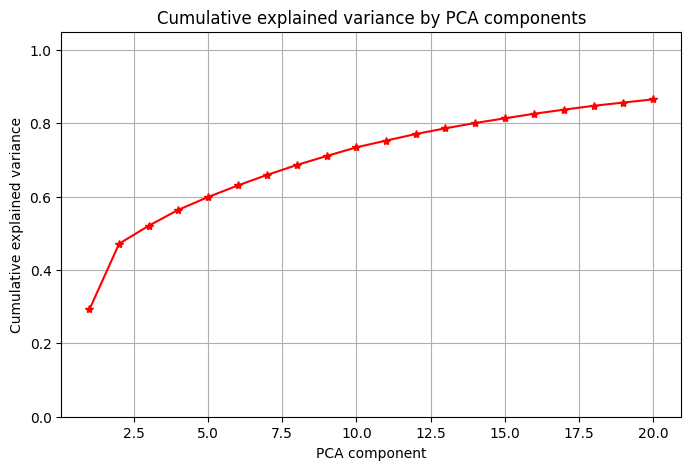

In [20]:
import matplotlib.pyplot as plt
cumsum_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, n_components+1), cumsum_variance_ratio, marker='*', color='red')
plt.xlabel('PCA component')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative explained variance by PCA components')
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

Za smanjenje dimenzionalnosti 168 numeričkih atributa koristila sam PCA, koja transformiše originalne atribute u linearno nekorelirane komponente.

Odabrano je 20 komponenti, što objašnjava ~86% ukupne varijanse i predstavlja kompromis između očuvanja informacija i smanjenja kompleksnosti modela.

In [21]:
processed_path = "../data/processed"
df_train_pca.to_csv(os.path.join(processed_path, "df_train_pca.csv"), index=False)
df_test_pca.to_csv(os.path.join(processed_path, "df_test_pca.csv"), index=False)

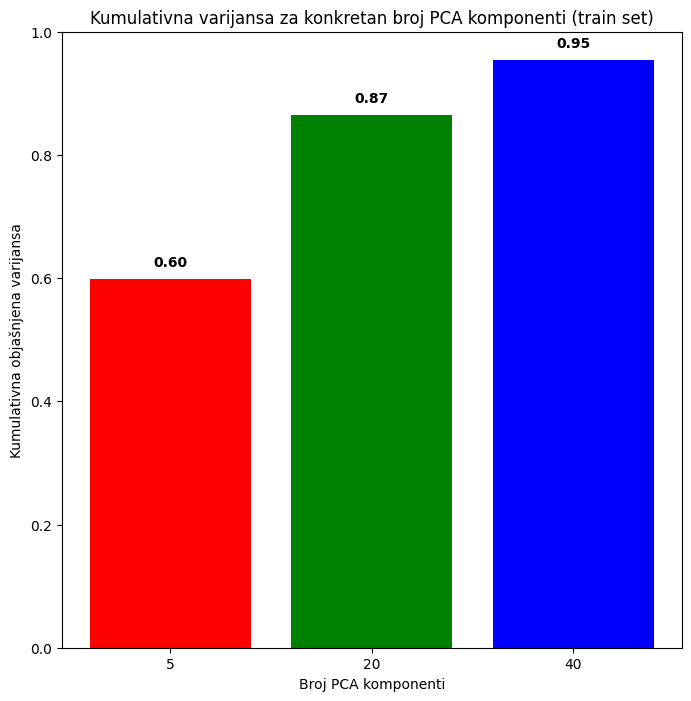

In [22]:
#eksperimentisanje
max_components = 40
pca_full = PCA(n_components=max_components)

X_train_pca_full = pca_full.fit_transform(X_train_scaled)
cumsum_var_train = np.cumsum(pca_full.explained_variance_ratio_)
components_to_plot = [5, 20, 40]
cumulative_variances = [cumsum_var_train[n-1] for n in components_to_plot]

plt.figure(figsize=(8,8))
plt.bar([str(n) for n in components_to_plot], cumulative_variances, color=['red', 'green', 'blue'])
plt.xlabel('Broj PCA komponenti')
plt.ylabel('Kumulativna objašnjena varijansa')
plt.title('Kumulativna varijansa za konkretan broj PCA komponenti (train set)')
plt.ylim(0, 1)
for i, v in enumerate(cumulative_variances):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()